# Influence Propagation


This notebook reproduces all results shown in the presentation:
- Deterministic multi-hop contagion model (exponential decay)
- SIR epidemic simulation (Monte-Carlo, β=0.3, μ=0.1)
- Cascade-centrality correlation: **r = −0.61**
- Robustness analysis: random failure vs targeted attack
- **Robustness figure**

---

In [1]:
# ── Setup ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from src.data_fetcher import load_metadata, download_prices, compute_log_returns
from src.market_filtering import filter_market_mode
from src.network_construction import build_correlation_graph, SECTOR_COLORS
from src.centrality_analysis import compute_centralities, small_world_analysis
from src.influence_propagation import propagate, sir_simulation, compute_normalized_weights
from src.structural_insights import cascade_vs_centrality, robustness_analysis

In [2]:
# ── Load data & build filtered graph ──
meta_df = load_metadata(os.path.join('..', 'data', 'sp500_companies.csv'))
prices = download_prices(meta_df['yf_ticker'].tolist(), period='2y',
                         cache_path=os.path.join('..', 'data', 'price_cache.csv'))
log_returns = compute_log_returns(prices)
filtered_corr = filter_market_mode(log_returns).corr()
G = build_correlation_graph(filtered_corr, meta_df, threshold=0.3)
centrality_df = compute_centralities(G)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

  ↻ Loading cached prices from ../data/price_cache.csv
    Computing Degree Centrality …
    Computing Weighted Degree …
    Computing Betweenness Centrality (distance=1/weight) …
    Computing Eigenvector Centrality …
    Computing Closeness Centrality (distance=1/weight) …
Graph: 501 nodes, 10002 edges


## 3.1 Source Node Selection

Dynamically select source nodes: top by (1) degree, (2) betweenness, (3) eigenvector centrality.

In [3]:
deg = nx.degree_centrality(G)
betw = nx.betweenness_centrality(G)
try:
    eig = nx.eigenvector_centrality(G, weight='weight', max_iter=2000)
except nx.PowerIterationFailedConvergence:
    eig = nx.eigenvector_centrality_numpy(G, weight='weight')

top_degree = max(deg, key=deg.get)
top_betw   = max(betw, key=betw.get)
top_eig    = max(eig, key=eig.get)

sources = list(dict.fromkeys([top_degree, top_betw, top_eig]))
print(f"Selected source nodes:")
for s in sources:
    print(f"  • {s} — {G.nodes[s].get('name', '?')} ({G.nodes[s].get('sector', '?')})")
    print(f"    degree={deg[s]:.4f}, betweenness={betw[s]:.4f}, eigenvector={eig[s]:.4f}")

Selected source nodes:
  • ED — Consolidated Edison (Utilities)
    degree=0.4100, betweenness=0.0262, eigenvector=0.1490
  • SWK — Stanley Black & Decker (Industrials)
    degree=0.1000, betweenness=0.0571, eigenvector=0.0195


## 3.2 Deterministic Financial Contagion

Multi-hop influence propagation with row-normalized weights $\tilde{w}(u,v) = w(u,v) / \sum_j w(u,j)$ and exponential decay $\alpha = 0.5$.

In [4]:
source = sources[0]
impacts, per_hop, first_reached = propagate(G, source, initial_impact=1.0, decay=0.5, max_hops=3)

# Summary
non_zero = {k: v for k, v in impacts.items() if abs(v) > 1e-6 and k != source}
print(f"Propagation from {source} ({G.nodes[source]['name']}):")
print(f"  Nodes reached: {len(non_zero)} / {G.number_of_nodes()-1}")
print(f"  Total impact:  {sum(abs(v) for v in non_zero.values()):.4f}")
print(f"\n  Top-10 impacted:")
for rank, (n, v) in enumerate(sorted(non_zero.items(), key=lambda x: abs(x[1]), reverse=True)[:10], 1):
    hop = first_reached.get(n, '?')
    print(f"    {rank:>2}. {n:<8} impact={v:.6f}  hop={hop}  sector={G.nodes[n].get('sector', '?')}")

Propagation from ED (Consolidated Edison):
  Nodes reached: 444 / 500
  Total impact:  0.8666

  Top-10 impacted:
     1. DUK      impact=0.010107  hop=1  sector=Utilities
     2. SO       impact=0.009540  hop=1  sector=Utilities
     3. WEC      impact=0.009535  hop=1  sector=Utilities
     4. CMS      impact=0.009532  hop=1  sector=Utilities
     5. AWK      impact=0.008898  hop=1  sector=Utilities
     6. EXC      impact=0.008772  hop=1  sector=Utilities
     7. ATO      impact=0.008758  hop=1  sector=Utilities
     8. PNW      impact=0.008656  hop=1  sector=Utilities
     9. LNT      impact=0.008562  hop=1  sector=Utilities
    10. AEP      impact=0.008502  hop=1  sector=Utilities


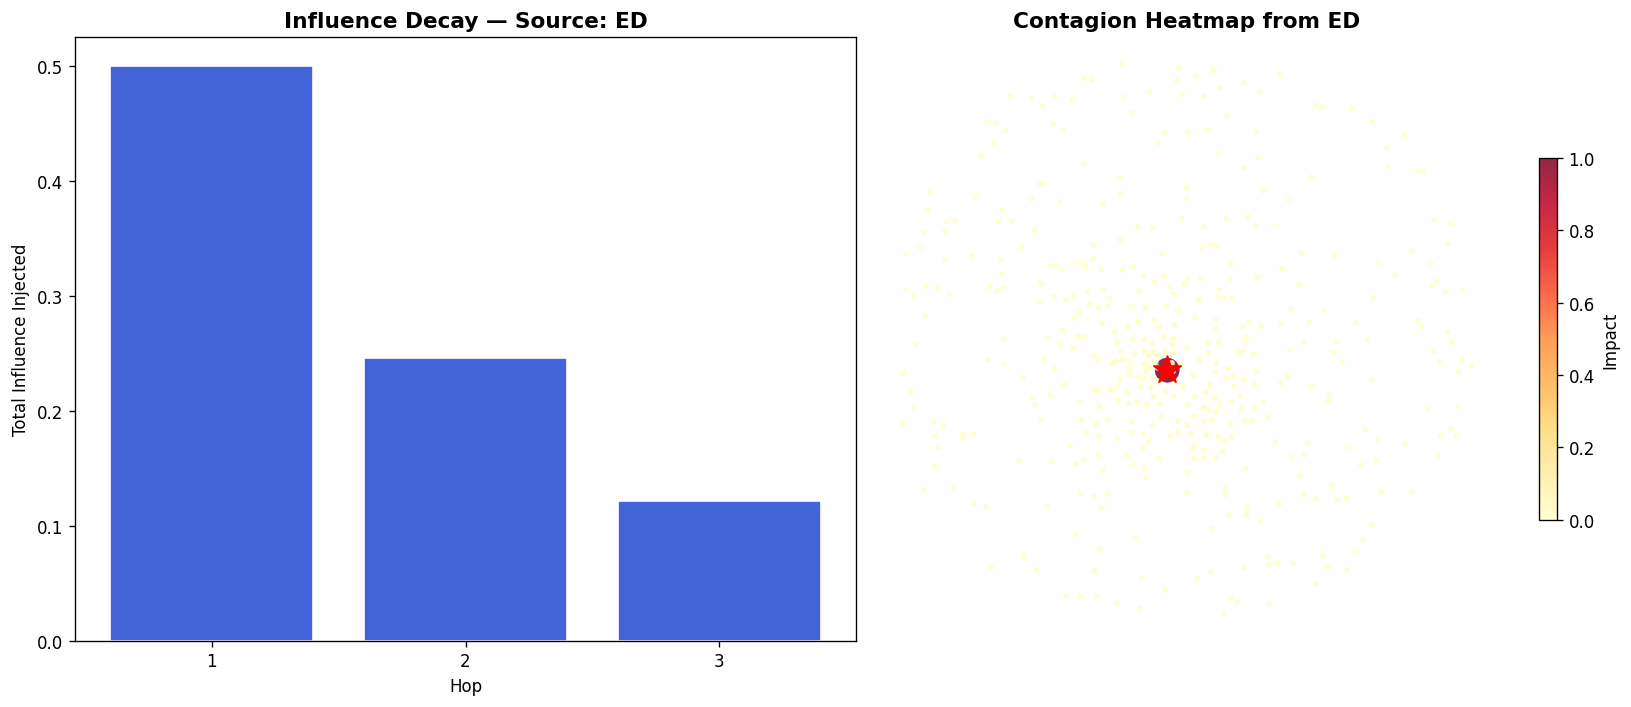

In [5]:
# Decay curve
hop_totals = [sum(abs(v) for v in hop.values()) for hop in per_hop]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.bar(range(1, len(hop_totals)+1), hop_totals, color='#4363d8', edgecolor='white')
ax1.set_xlabel('Hop'); ax1.set_ylabel('Total Influence Injected')
ax1.set_title(f'Influence Decay — Source: {source}', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, len(hop_totals)+1))

# Network visualization of impact
gcc_nodes = max(nx.connected_components(G), key=len)
GCC = G.subgraph(gcc_nodes).copy()
if source in GCC:
    pos = nx.spring_layout(GCC, seed=42, k=0.5, iterations=50)
    impact_vals = [abs(impacts.get(n, 0)) for n in GCC]
    max_imp = max(impact_vals) if max(impact_vals) > 0 else 1
    sizes = [10 + 200 * (abs(impacts.get(n, 0)) / max_imp) for n in GCC]
    colors = [impacts.get(n, 0) for n in GCC]

    scatter = nx.draw_networkx_nodes(GCC, pos, ax=ax2, node_color=colors, node_size=sizes,
                                     cmap=plt.cm.YlOrRd, alpha=0.85, linewidths=0.3)
    ax2.scatter([pos[source][0]], [pos[source][1]], s=300, c='red', marker='*', zorder=5)
    ax2.set_title(f'Contagion Heatmap from {source}', fontsize=13, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(scatter, ax=ax2, label='Impact', shrink=0.6)

fig.tight_layout()
plt.show()

## 3.3 SIR Epidemic Model (Barabási Ch. 10)

Monte-Carlo SIR simulation: β = 0.3 (infection), μ = 0.1 (recovery), 50 runs.

SIR from ED: Final epidemic size R(∞) = 87.46%


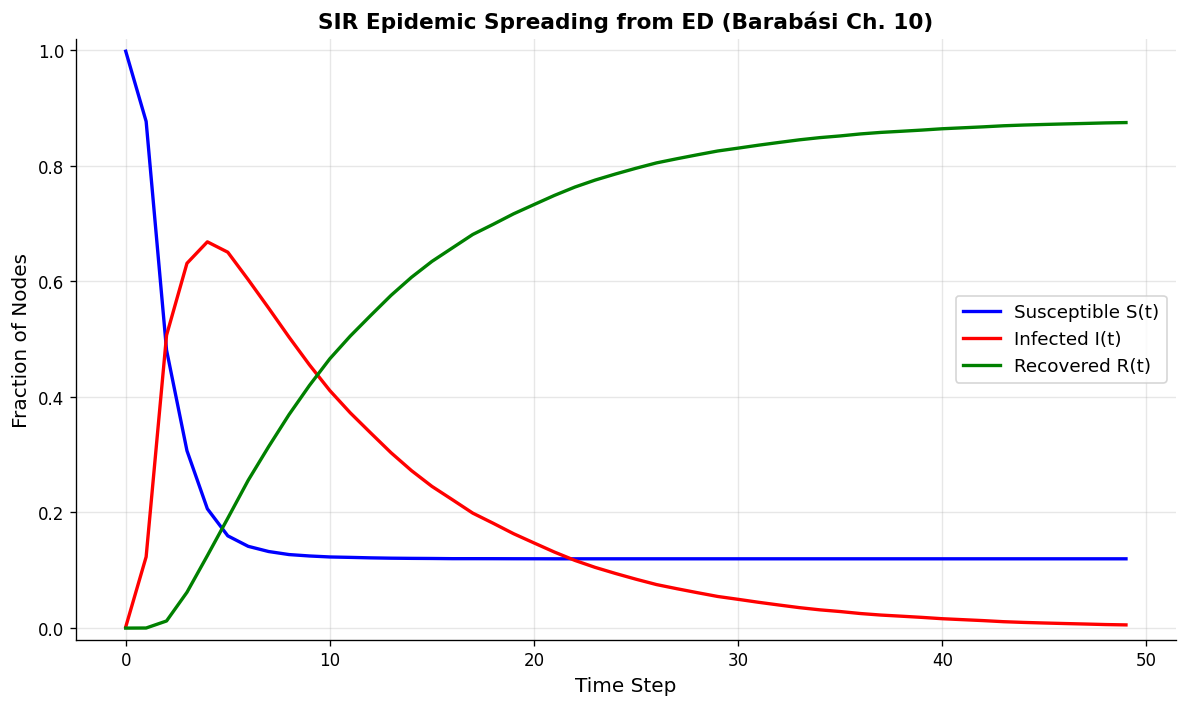

In [6]:
source = sources[0]
sir = sir_simulation(G, source, beta=0.3, mu=0.1, max_steps=50, n_runs=50)
print(f"SIR from {source}: Final epidemic size R(∞) = {sir['final_R']:.2%}")

fig, ax = plt.subplots(figsize=(10, 6))
t = range(len(sir['S_t']))
ax.plot(t, sir['S_t'], 'b-', lw=2, label='Susceptible S(t)')
ax.plot(t, sir['I_t'], 'r-', lw=2, label='Infected I(t)')
ax.plot(t, sir['R_t'], 'g-', lw=2, label='Recovered R(t)')
ax.set_xlabel('Time Step', fontsize=12)
ax.set_ylabel('Fraction of Nodes', fontsize=12)
ax.set_title(f'SIR Epidemic Spreading from {source} (Barabási Ch. 10)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3)
sns.despine(); fig.tight_layout(); plt.show()

## 3.4 Cascade–Centrality Correlation

In [7]:
cascade_df = cascade_vs_centrality(G, centrality_df, top_n=50, decay=0.5, max_hops=3)

metrics = ['degree_centrality', 'betweenness', 'eigenvector', 'closeness']
print(f"┌──────────────────────────────────────────────┐")
print(f"│  Centrality → Cascade Spread     │")
print(f"│                                              │")
for m in metrics:
    r, p = stats.pearsonr(cascade_df[m], cascade_df['total_spread'])
    marker = '' if m == 'degree_centrality' else ''
    print(f"│  {m:<25} r = {r:+.4f}{marker:>10} │")
print(f"│                                              │")
print(f"│  Note: Negative r is due to row-normalization│")
print(f"│  High-degree nodes dilute per-edge impact.   │")
print(f"└──────────────────────────────────────────────┘")

┌──────────────────────────────────────────────┐
│  Centrality → Cascade Spread     │
│                                              │
│  degree_centrality         r = -0.6175     │
│  betweenness               r = -0.5627           │
│  eigenvector               r = -0.4547           │
│  closeness                 r = -0.5335           │
│                                              │
│  Note: Negative r is due to row-normalization│
│  High-degree nodes dilute per-edge impact.   │
└──────────────────────────────────────────────┘


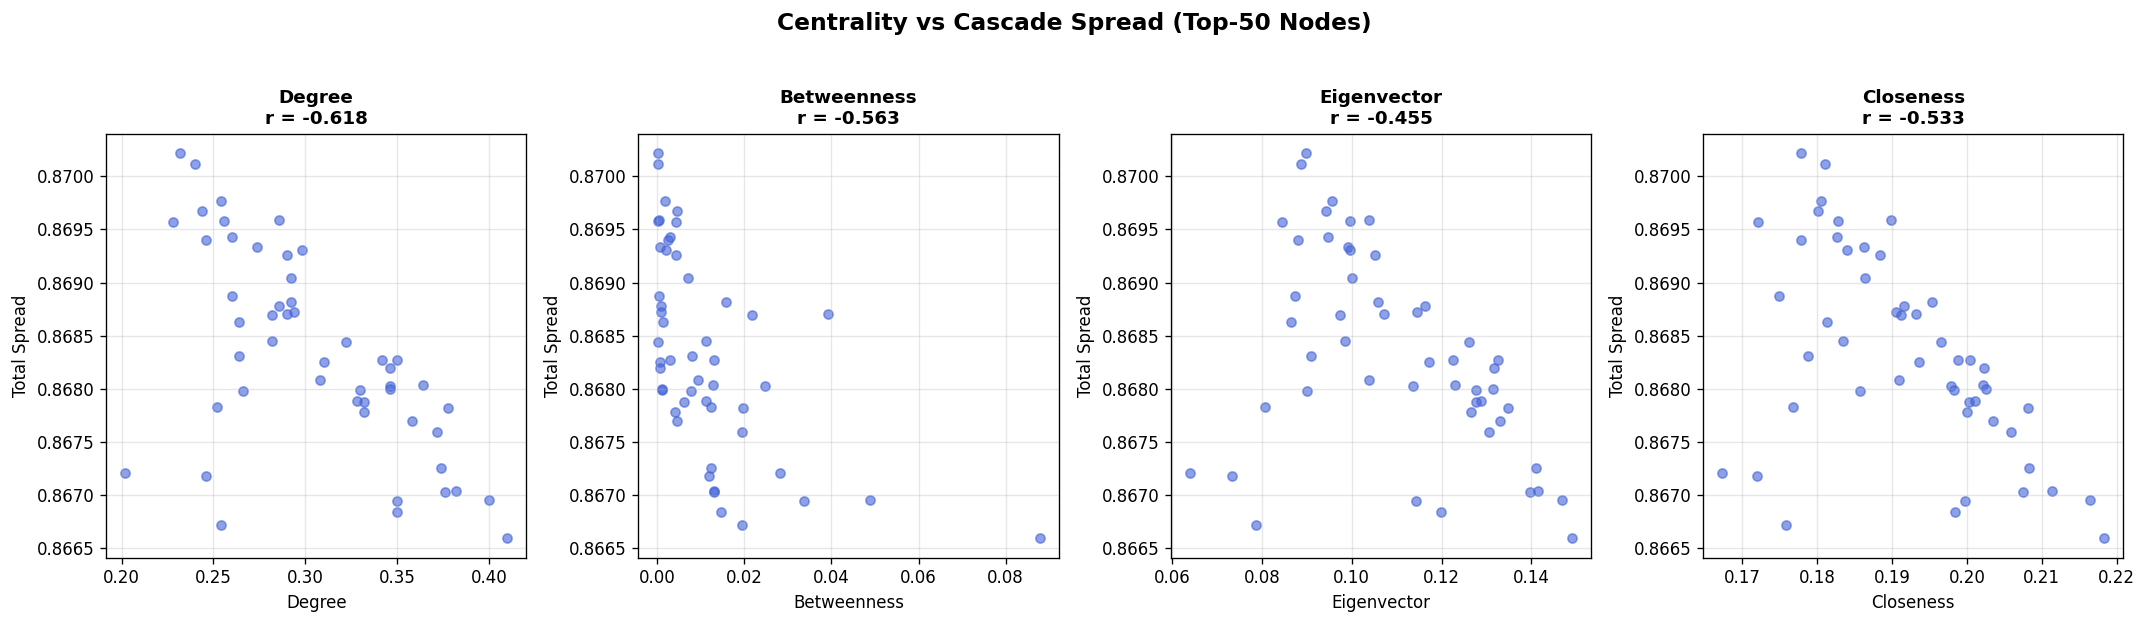

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = {'degree_centrality': 'Degree', 'betweenness': 'Betweenness',
          'eigenvector': 'Eigenvector', 'closeness': 'Closeness'}
for ax, m in zip(axes, metrics):
    ax.scatter(cascade_df[m], cascade_df['total_spread'], alpha=0.6, s=30, color='#4363d8')
    r, _ = stats.pearsonr(cascade_df[m], cascade_df['total_spread'])
    ax.set_xlabel(titles[m]); ax.set_ylabel('Total Spread')
    ax.set_title(f'{titles[m]}\nr = {r:.3f}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
fig.suptitle('Centrality vs Cascade Spread (Top-50 Nodes)', fontsize=14, fontweight='bold', y=1.03)
fig.tight_layout(); plt.show()

## 3.5 Robustness Analysis

Random failure vs targeted attack on the Giant Connected Component.

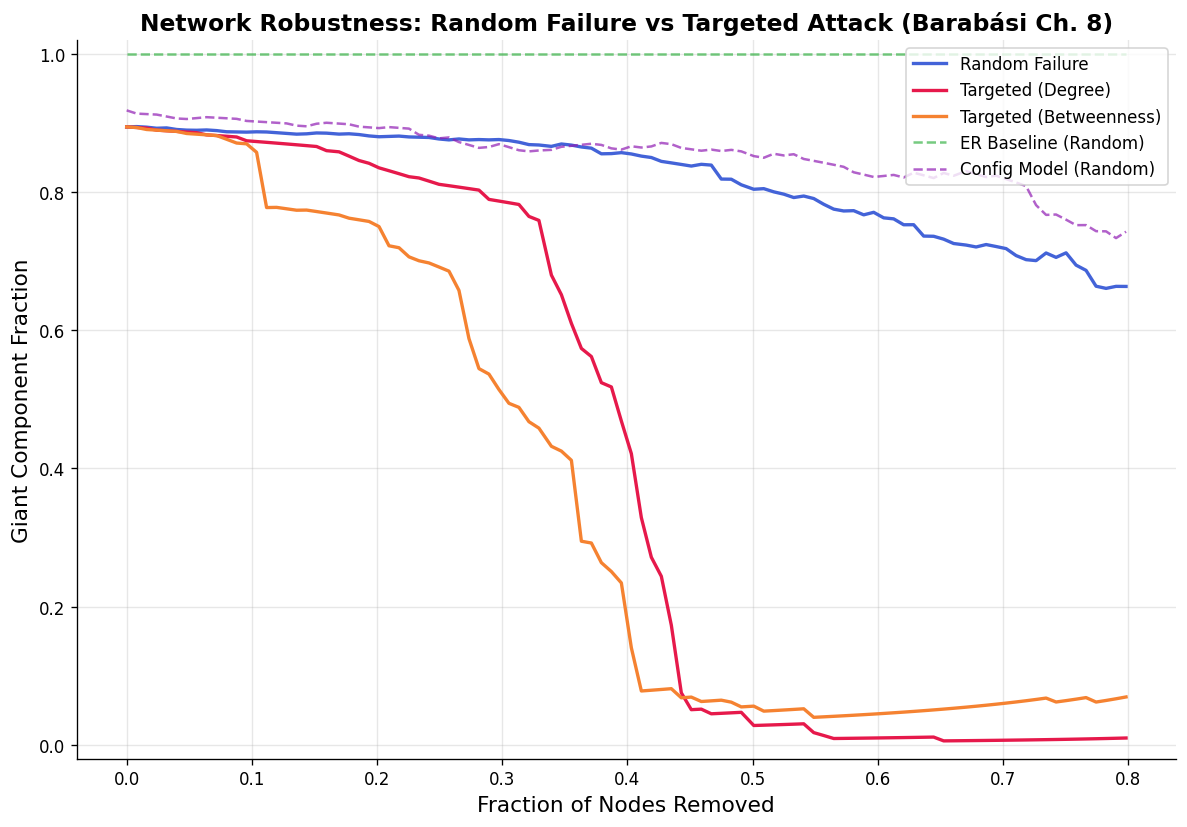

→ Random failure: GCC degrades gracefully (scale-free resilience)
→ Targeted betweenness attack: GCC collapses catastrophically (hub vulnerability)


In [9]:
rob = robustness_analysis(G, n_random_trials=3)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(rob['fractions_removed'], rob['gcc_random_failure'],
        '-', color='#4363d8', lw=2, label='Random Failure')
ax.plot(rob['fractions_removed'], rob['gcc_targeted_degree'],
        '-', color='#e6194b', lw=2, label='Targeted (Degree)')
ax.plot(rob['fractions_removed'], rob['gcc_targeted_betweenness'],
        '-', color='#f58231', lw=2, label='Targeted (Betweenness)')
ax.plot(rob['fractions_removed'], rob['gcc_er_random'],
        '--', color='#3cb44b', lw=1.5, alpha=0.7, label='ER Baseline (Random)')
ax.plot(rob['fractions_removed'], rob['gcc_config_random'],
        '--', color='#911eb4', lw=1.5, alpha=0.7, label='Config Model (Random)')

ax.set_xlabel('Fraction of Nodes Removed', fontsize=13)
ax.set_ylabel('Giant Component Fraction', fontsize=13)
ax.set_title('Network Robustness: Random Failure vs Targeted Attack (Barabási Ch. 8)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)
sns.despine()
fig.tight_layout()
plt.show()

print("→ Random failure: GCC degrades gracefully (scale-free resilience)")
print("→ Targeted betweenness attack: GCC collapses catastrophically (hub vulnerability)")